In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.python import tech_colors, ssp_colors

# Set LaTeX style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.2,
    'lines.linewidth': 1.5,
})


In [2]:
# Load data

# td_production_old = td_production.copy()
td_production = pd.read_csv("output/operations/production_details.csv")
td_production = td_production[["SSP","Decade","Technology","Day","Hour","Balance"]].groupby(["SSP","Decade","Technology","Day","Hour"]).sum().reset_index().rename(columns = {'Balance':'Value'})
tech_order = ['GSHP', 'ASHP', 'E_boiler', 'NG_boiler']  # Your desired order
tech_cat = pd.CategoricalDtype(tech_order, ordered=True)
td_production['Technology'] = td_production['Technology'].astype(tech_cat)

td_production = td_production.sort_values(['SSP', 'Decade', 'Day', 'Hour', 'Technology'])

td_losses = pd.read_csv("output/operations/TD_losses.csv")
td_weight = pd.read_csv("data/inputs/preprocessed_weights.csv")[['gcm','ssp','decade','td','weight']].rename(columns={'ssp':'SSP','decade':'Decade','td':'Day'})
td_weight = td_weight[['SSP','Decade','Day','weight']].groupby(['SSP','Decade','Day']).mean().reset_index()

mask = td_weight['Decade'] == '2020s'
past_weight = td_weight[mask][['Decade','Day','weight']].groupby(['Decade','Day']).mean().reset_index()
past_weight['SSP'] = 'past'
future_weight = td_weight[~mask][['SSP','Decade','Day','weight']].groupby(['SSP','Decade','Day']).mean().reset_index()

td_weight = pd.concat([past_weight,future_weight])
print(pd.concat([past_weight,future_weight]))
td_production

    Decade  Day      weight     SSP
0    2020s    0   83.750000    past
1    2020s    1  228.500000    past
2    2020s    2  374.458333    past
3    2020s    3  433.291667    past
4    2020s    4  322.541667    past
..     ...  ...         ...     ...
507  2100s   11   18.200000  ssp585
508  2100s   12   24.400000  ssp585
509  2100s   13   31.800000  ssp585
510  2100s   14   32.200000  ssp585
511  2100s   15   30.800000  ssp585

[528 rows x 4 columns]


,SSP,Decade,Technology,Day,Hour,Value
768,past,2020s,GSHP,0,0,0.000000
0,past,2020s,ASHP,0,0,0.000000
384,past,2020s,E_boiler,0,0,0.000000
1152,past,2020s,NG_boiler,0,0,0.000000
769,past,2020s,GSHP,0,1,0.000000
...,...,...,...,...,...,...
44542,ssp585,2090s,NG_boiler,15,22,0.000000
44159,ssp585,2090s,GSHP,15,23,-711.111111
43391,ssp585,2090s,ASHP,15,23,-2011.731913
43775,ssp585,2090s,E_boiler,15,23,0.000000


['ssp126' 'ssp245' 'ssp370' 'ssp585']
['2020s', '2030s', '2040s', '2050s', '2060s', '2070s', '2080s', '2090s']
      SSP Decade  InvestmentCost      OPEX   CO2_tax
0    past  2020s        4.107882  1.521816  0.016219
1  ssp126  2030s        0.000000  1.238195  0.111253
2  ssp126  2040s        2.691324  1.323227  0.121908
3  ssp126  2050s        0.000000  1.375989  0.059441
4  ssp126  2060s        2.503400  1.342922  0.061686
5  ssp126  2070s        1.018400  1.314656  0.062150
6  ssp126  2080s        2.413612  1.331696  0.058686
7  ssp126  2090s        0.000000  1.339263  0.057649
       SSP Decade  InvestmentCost      OPEX   CO2_tax
0     past  2020s        4.107882  1.521816  0.016219
8   ssp245  2030s        0.017387  1.139939  0.030118
9   ssp245  2040s        2.751935  1.175211  0.028248
10  ssp245  2050s        0.029116  1.222711  0.032478
11  ssp245  2060s        2.513315  1.263138  0.042934
12  ssp245  2070s        1.018400  1.250594  0.037610
13  ssp245  2080s        2.410253 

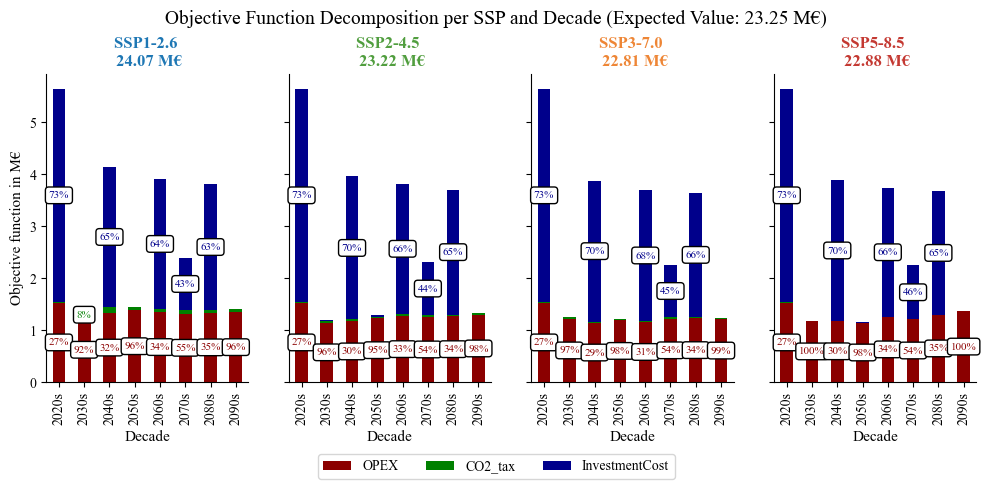

In [3]:
exp_colors = {"OPEX":"darkred",
              "CO2_tax":"green",
              "InvestmentCost":"darkblue"}

td_opex = pd.read_csv("output/operations/production_details.csv")
td_opex = td_opex[["SSP","Decade","Day","Hour","OPEX","CO2_tax"]].groupby(["SSP","Decade","Day","Hour"]).sum().reset_index()

joined_df = td_opex.merge(td_weight, on=['SSP', 'Decade', 'Day'])
joined_df['OPEX'] = joined_df['OPEX'] * joined_df['weight']  # / 10 years / 1000 kWh -> MWh
joined_df['CO2_tax'] = joined_df['CO2_tax'] * joined_df['weight']  # / 10 years / 1000 kWh -> MWh
df = joined_df.copy()

# Group by SSP, Decade, Technology, Sign and sum values
grouped = df.groupby(['SSP', 'Decade']).agg({
    'OPEX': 'sum',
    'CO2_tax' :'sum'
}).reset_index()

investment = pd.read_csv("output/design/investment_details.csv")

investment = investment[['SSP', 'Decade','InvestmentCost']].groupby(['SSP', 'Decade']).agg({
    'InvestmentCost': 'sum'
}).reset_index()

obj = pd.merge(left = investment, right = grouped, on = ['SSP', 'Decade'])
obj[["InvestmentCost","OPEX","CO2_tax"]] /= 1e6

# Get unique SSPs, Decades, Technologies, and Signs
ssps = obj[obj['SSP'] != 'past']['SSP'].unique()
print(ssps)
decades = sorted(obj['Decade'].unique())
print(decades)

# Create subplots
fig, axes = plt.subplots(1, len(ssps), figsize=(3*len(ssps), 4), sharey=True)
if len(ssps) == 1:
    axes = [axes]

scen_val = 0
# Create bar plots for each SSP
for idx, ssp in enumerate(ssps):
    ax = axes[idx]
    ssp_data = obj[(obj['SSP'] == ssp) | (obj['SSP'] == 'past')]
    print(ssp_data)
    # Create stacked bar plot
    ssp_data[["Decade","OPEX","CO2_tax","InvestmentCost"]].plot(
        x='Decade', 
        kind='bar',  # Specify bar plot
        stacked=True,  # Make it stacked
        ax=ax, 
        color = [exp_colors[type] for type in ["OPEX","CO2_tax","InvestmentCost"]],
        legend = False,
    )
    ssp_formatted = f"SSP{ssp[3]}-{ssp[4]}.{ssp[5]}"
    ax.set_title(f'{ssp_formatted} \n {ssp_data[["InvestmentCost","OPEX","CO2_tax"]].sum().sum():.2f} M€', fontdict={'color':ssp_colors[ssp_formatted]})
    scen_val += ssp_data[["InvestmentCost","OPEX","CO2_tax"]].sum().sum()
    if idx == 0 :
        ax.set_ylabel("Objective function in M€")
        # Annotate stacked bars with percentage contribution
    categories = ["OPEX", "CO2_tax", "InvestmentCost"]

    for i, decade in enumerate(ssp_data["Decade"]):
        values = ssp_data.loc[ssp_data["Decade"] == decade, categories].values.flatten()
        total = values.sum()
        bottom = 0.0

        for val, cat in zip(values, categories):
            if val <= 0:
                bottom += val
                continue

            pct = val / total * 100
            if pct > 5:
                ax.text(
                    i,
                    bottom + val / 2,
                    f"{pct:.0f}%",
                    ha='center',
                    va='center',
                    fontsize=8,
                    color=exp_colors[cat],
                    bbox=dict(facecolor='white', edgecolor='k', 
                                boxstyle='round,pad=0.3')
                )
            bottom += val


    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.15))


fig.suptitle(f"Objective Function Decomposition per SSP and Decade (Expected Value: {scen_val/len(ssps):.2f} M€)", y=1.04, fontsize=14)
# plt.suptitle('Main Title')
# Compute average of each decade across all SSPs
decade_avg = obj.groupby('Decade').mean(numeric_only=True)

# Sum all values across all decades
total_sum = decade_avg.sum()

print("Expected value across decade:")
print(decade_avg)
print("\nSubtotal sum per category:")
print(total_sum)
print("\nExpected Value:")
print(f"{total_sum.sum():.2e}")

fig.savefig('output/overview.pdf', dpi = 600, bbox_inches='tight')
fig.savefig('output/overview.png', dpi = 600, bbox_inches='tight')
